# Cuaderno 4 — Modelos OLS por segmento de precio

El precio de una vivienda no crece igual con la superficie en todos los segmentos del mercado. Es probable que cada metro cuadrado adicional *valga más* en un piso de gama alta que en uno de gama baja.

En este cuaderno comprobamos esa hipótesis dividiendo el mercado en **cuatro cuartiles de precio** y estimando un modelo OLS independiente para cada segmento.

Los pasos son estos:
1. Dividir `precio_euros` en cuatro cuartiles (Q1–Q4)
2. Estimar un OLS *stepwise* por cuartil
3. Comparar el coeficiente de `superficie` entre cuartiles
4. Crear la variable `beta_superficie`: el coeficiente que le corresponde a cada oferta según su segmento de precio
5. Cartografiar `beta_superficie` y su distribución espacial

## 🔧 Configuración inicial

Estas celdas cargan las librerías necesarias, montan Google Drive y cargan los datos generados por el Cuaderno 1.


In [1]:
# ─── Librerías ───────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
import os

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
from scipy.stats import gaussian_kde
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# ✏️ MODIFICA AQUÍ — Ruta al archivo guardado por el Cuaderno 1 en tu Drive
RUTA_DATOS = "/content/drive/MyDrive/srgvua/datos_para_cuaderno2.gpkg"

# ─── Cargar datos ─────────────────────────────────────────────────────────────
print("⏳ Cargando datos...")
gdf = gpd.read_file(RUTA_DATOS)
print(f"✅ Datos cargados: {gdf.shape[0]:,} filas × {gdf.shape[1]} columnas")
print(f"   Proyección: {gdf.crs}")

Mounted at /content/drive
⏳ Cargando datos...
✅ Datos cargados: 9,168 filas × 53 columnas
   Proyección: EPSG:25831


In [4]:
# ─── Crear columnas derivadas si no existen ───────────────────────────────────
if 'superficie_2' not in gdf.columns:
    gdf['superficie_2'] = gdf['superficie'] ** 2
    print("✅ Variable 'superficie_2' creada")

if 'log_precio_euros' not in gdf.columns:
    gdf['log_precio_euros'] = np.log(gdf['precio_euros'])
    print("✅ Variable 'log_precio_euros' creada")

# ─── Configuración del análisis ───────────────────────────────────────────────

# Variables siempre incluidas en todos los modelos
VARS_FORZADAS = ['superficie', 'superficie_2']

# Variable dependiente (logaritmo del precio, igual que en el Cuaderno 1)
COL_Y = 'log_precio_euros'

# Variable sobre la que se crean los cuartiles -- ✏️ PUEDES MODIFICARLA
COL_PRECIO_CUARTIL = 'precio_euros'

# Colores para identificar cada cuartil (se usan en histogramas y mapas)
COLORES_CUARTIL = {
    'Q1': '#2166ac',   # azul   → precios más bajos
    'Q2': '#74add1',   # azul claro
    'Q3': '#fdae61',   # naranja
    'Q4': '#d73027',   # rojo   → precios más altos
}

print(f"   Variable dependiente : {COL_Y}")
print(f"   Variable de cuartiles: {COL_PRECIO_CUARTIL}")
print(f"   Variables forzadas   : {VARS_FORZADAS}")

   Variable dependiente : log_precio_euros
   Variable de cuartiles: precio_euros
   Variables forzadas   : ['superficie', 'superficie_2']


### 🛠️ Funciones auxiliares

Las funciones de este cuaderno están centralizadas aquí. Son las mismas del Cuaderno 1 (más una nueva para mapas de puntos), por lo que no es necesario modificarlas.


In [5]:
# ─── Funciones auxiliares ────────────────────────────────────────────────────

def tabla_vif(X_df, variables, nombre_modelo=''):
    """
    Muestra la tabla de VIF (Factor de Inflación de la Varianza).
    VIF > 5 → multicolinealidad moderada; VIF > 10 → severa.
    """
    vif = pd.DataFrame({
        'Variable': variables,
        'VIF': [variance_inflation_factor(X_df.values, i + 1)
                for i in range(len(variables))]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)
    vif['VIF'] = vif['VIF'].round(2)
    titulo = f"TABLA DE VIF{' — ' + nombre_modelo if nombre_modelo else ''}"
    print(titulo)
    display(vif)


def stepwise_aic(y, vars_forzadas, vars_candidatas, datos):
    """
    Selección de variables por AIC (forward-backward stepwise).
    - vars_forzadas  : siempre presentes en el modelo.
    - vars_candidatas: se evalúan para entrar o salir del modelo.
    Retorna la lista final de variables seleccionadas (incluyendo las forzadas).
    """
    incluidas  = list(vars_forzadas)
    candidatas = list(vars_candidatas)
    aic_actual = sm.OLS(y, sm.add_constant(datos[incluidas])).fit().aic
    mejora     = True

    while mejora:
        mejora = False

        # ── Forward: probar añadir cada candidata ──
        mejor_aic_fwd, mejor_add = aic_actual, None
        for var in candidatas:
            aic_p = sm.OLS(y, sm.add_constant(datos[incluidas + [var]])).fit().aic
            if aic_p < mejor_aic_fwd:
                mejor_aic_fwd, mejor_add = aic_p, var
        if mejor_add:
            incluidas.append(mejor_add)
            candidatas.remove(mejor_add)
            aic_actual = mejor_aic_fwd
            mejora = True

        # ── Backward: probar eliminar las no forzadas ──
        mejor_aic_bwd, mejor_rem = aic_actual, None
        for var in [v for v in incluidas if v not in vars_forzadas]:
            vars_sin = [v for v in incluidas if v != var]
            aic_p = sm.OLS(y, sm.add_constant(datos[vars_sin])).fit().aic
            if aic_p < mejor_aic_bwd:
                mejor_aic_bwd, mejor_rem = aic_p, var
        if mejor_rem:
            incluidas.remove(mejor_rem)
            candidatas.append(mejor_rem)
            aic_actual = mejor_aic_bwd
            mejora = True

    return incluidas


def diagnostico_residuos(modelo, titulo='Modelo'):
    """
    Genera un gráfico P-P y un gráfico de homocedasticidad para un modelo OLS.
    """
    residuos          = modelo.resid
    valores_ajustados = modelo.fittedvalues
    resid_std         = (residuos - residuos.mean()) / residuos.std()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Gráfico P-P ──
    n         = len(resid_std)
    probs_obs = np.arange(1, n + 1) / (n + 1)
    probs_teo = stats.norm.cdf(np.sort(resid_std))
    axes[0].scatter(probs_teo, probs_obs, alpha=0.5, edgecolors='k', s=15, color='steelblue')
    axes[0].plot([0, 1], [0, 1], 'r--', linewidth=2, label='Referencia (normal perfecta)')
    axes[0].set_xlabel('Probabilidades teóricas (normal)', fontsize=10)
    axes[0].set_ylabel('Probabilidades observadas', fontsize=10)
    axes[0].set_title(f'Gráfico P-P — {titulo}', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)

    # ── Homocedasticidad ──
    axes[1].scatter(valores_ajustados, resid_std, alpha=0.4, s=15,
                    color='tomato', edgecolors='k', linewidths=0.3)
    axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
    axes[1].set_xlabel('Valores ajustados (ŷ)', fontsize=10)
    axes[1].set_ylabel('Residuos estandarizados', fontsize=10)
    axes[1].set_title(f'Homocedasticidad — {titulo}', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def mapa_puntos(gdf_plot, col_valor, titulo, cmap='RdYlGn',
                vmin=None, vmax=None, markersize=4, label_leyenda='Valor'):
    """
    Mapa de puntos coloreado por el valor de una columna.
    Los límites de color se calculan automáticamente en los percentiles 5-95
    (o se pueden pasar manualmente con vmin/vmax).
    """
    datos = gdf_plot[gdf_plot[col_valor].notna()].copy()
    if vmin is None:
        vmin = datos[col_valor].quantile(0.05)
    if vmax is None:
        vmax = datos[col_valor].quantile(0.95)

    fig, ax = plt.subplots(figsize=(10, 9))
    datos.plot(
        column=col_valor, cmap=cmap, ax=ax,
        alpha=0.5, markersize=markersize, linewidth=0,
        legend=True, vmin=vmin, vmax=vmax,
        legend_kwds={'label': label_leyenda, 'shrink': 0.7}
    )
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


print("✅ Funciones auxiliares definidas: stepwise_aic | tabla_vif | diagnostico_residuos | mapa_puntos")

✅ Funciones auxiliares definidas: stepwise_aic | tabla_vif | diagnostico_residuos | mapa_puntos


---
## Paso 1 — División de `precio_euros` en cuartiles

El primer paso es dividir el mercado en cuatro segmentos de precio de igual tamaño (cuartiles):

| Cuartil | Descripción |
|---|---|
| Q1 | 25 % de viviendas más baratas |
| Q2 | Segundo cuartil (precio medio-bajo) |
| Q3 | Tercer cuartil (precio medio-alto) |
| Q4 | 25 % de viviendas más caras |

Usamos `pd.qcut`, que crea grupos con el mismo número de observaciones en cada uno (no los mismos rangos de precio).


RESUMEN POR CUARTIL DE PRECIO
                n_obs  precio_min  precio_mediana  precio_medio  precio_max
cuartil_precio                                                             
Q1               2333     20000.0        190000.0      185821.0    250000.0
Q2               2269    260000.0        320000.0      320564.0    380000.0
Q3               2275    390000.0        460000.0      466215.0    580000.0
Q4               2291    590000.0        850000.0      992833.0   4810000.0


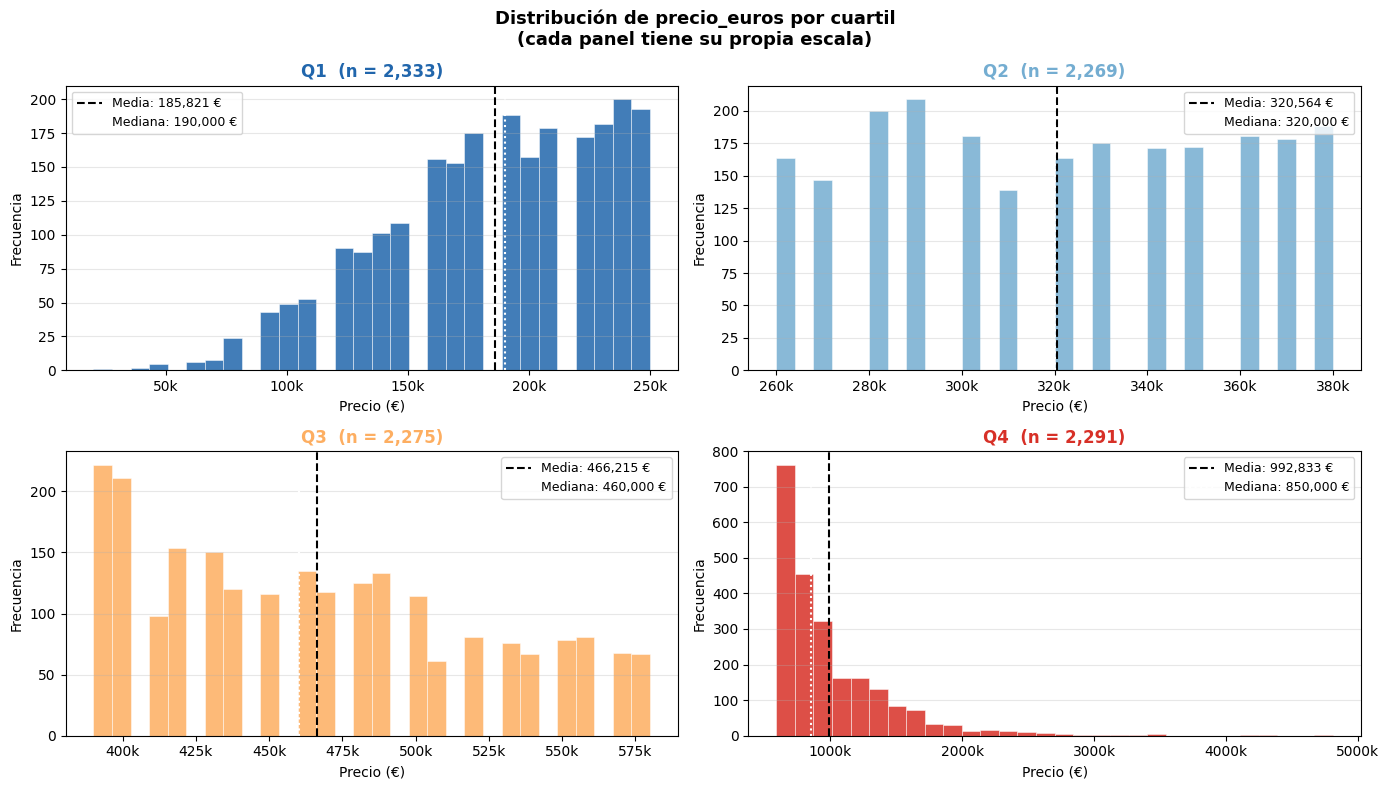

In [6]:
# ─── Crear variable de cuartil ────────────────────────────────────────────────
# pd.qcut divide en grupos de igual frecuencia (mismo número de obs. en cada uno)
gdf['cuartil_precio'] = pd.qcut(
    gdf[COL_PRECIO_CUARTIL],
    q=4,
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

# ─── Tabla resumen por cuartil ────────────────────────────────────────────────
resumen_cuartiles = gdf.groupby('cuartil_precio', observed=True)[COL_PRECIO_CUARTIL].agg(
    n_obs='count',
    precio_min='min',
    precio_mediana='median',
    precio_medio='mean',
    precio_max='max'
).round(0)

print("="*65)
print("RESUMEN POR CUARTIL DE PRECIO")
print("="*65)
print(resumen_cuartiles.to_string())
print("="*65)

# ─── Histogramas individuales por cuartil ─────────────────────────────────────

N_BINS = 30   # número de barras por panel

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (cuartil, color) in enumerate(COLORES_CUARTIL.items()):
    subset = gdf[gdf['cuartil_precio'] == cuartil][COL_PRECIO_CUARTIL].dropna()
    n      = len(subset)

    # Bordes explícitos: N_BINS intervalos iguales de min a max → sin huecos
    bins = np.linspace(subset.min(), subset.max(), N_BINS + 1)

    axes[i].hist(subset, bins=bins, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
    axes[i].axvline(subset.mean(),   color='black', linestyle='--', linewidth=1.5,
                    label=f'Media: {subset.mean():,.0f} €')
    axes[i].axvline(subset.median(), color='white', linestyle=':',  linewidth=1.5,
                    label=f'Mediana: {subset.median():,.0f} €')

    axes[i].set_title(f'{cuartil}  (n = {n:,})', fontsize=12, fontweight='bold', color=color)
    axes[i].set_xlabel('Precio (€)', fontsize=10)
    axes[i].set_ylabel('Frecuencia', fontsize=10)
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3, axis='y')
    axes[i].xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k')
    )

plt.suptitle('Distribución de precio_euros por cuartil\n(cada panel tiene su propia escala)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


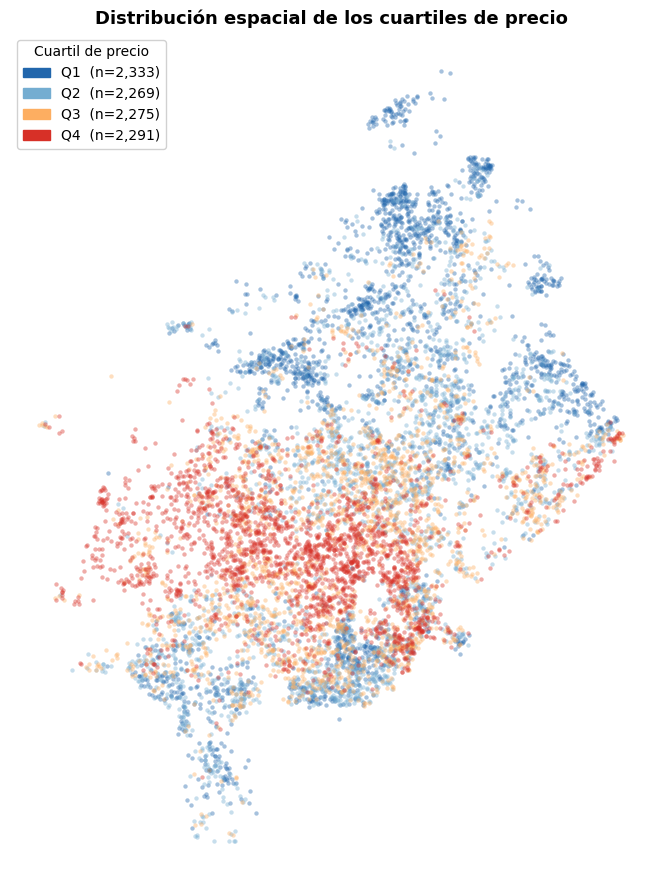

In [7]:
# ─── Mapa de distribución espacial de los cuartiles ──────────────────────────

fig, ax = plt.subplots(figsize=(10, 9))
for cuartil, color in COLORES_CUARTIL.items():
    subset = gdf[gdf['cuartil_precio'] == cuartil]
    subset.plot(ax=ax, color=color, markersize=10, alpha=0.4, linewidth=0)

ax.set_title('Distribución espacial de los cuartiles de precio', fontsize=13, fontweight='bold')
ax.axis('off')

patches = [
    mpatches.Patch(
        color=color,
        label=f'{q}  (n={len(gdf[gdf["cuartil_precio"] == q]):,})'
    )
    for q, color in COLORES_CUARTIL.items()
]
ax.legend(handles=patches, loc='upper left', fontsize=10,
          framealpha=0.9, title='Cuartil de precio')
plt.tight_layout()
plt.show()

---
## Paso 2 — Modelos OLS *stepwise* por cuartil

Para cada cuartil de precio estimamos un modelo OLS con **selección automática de variables por AIC** (*forward-backward stepwise*). Esto permite:

1. Ver qué variables explican mejor el precio en cada segmento del mercado.
2. Obtener un **coeficiente específico de `superficie`** para cada segmento.

> **Nota sobre la variable dependiente:** Usamos `log_precio_euros` (logaritmo natural del precio), igual que en el Cuaderno 1, porque mejora los supuestos del modelo. El coeficiente de `superficie` se interpreta como el **cambio porcentual aproximado** en el precio por cada m² adicional:
> $$\%\Delta\text{precio} \approx \hat{\beta}_{\text{superficie}} \times 100$$
> Por ejemplo, si β = 0.004, un m² adicional está asociado a un aumento del precio de ~0,4 %.


In [8]:
# ✏️ MODIFICA AQUÍ — Variables candidatas para el stepwise por cuartil
# Estas variables se evaluarán una a una en cada modelo.
# Las variables 'superficie' y 'superficie_2' SIEMPRE se incluyen (no las pongas aquí).
VARIABLES_CANDIDATAS = [
    'calidad_construccion',
    'interac_planta_ascensor',
    'desemp_pct',
    'rm_h',
    'viv_prip_pct',
    'ac',
    'calefaccion',
    'n_habs',
    'n_baños',
    'distancia_plaza_cat',
]

print(f"   Variables forzadas           : {VARS_FORZADAS}")
print(f"   Variables candidatas (step.) : {VARIABLES_CANDIDATAS}")
print(f"   Variable dependiente         : {COL_Y}")

   Variables forzadas           : ['superficie', 'superficie_2']
   Variables candidatas (step.) : ['calidad_construccion', 'interac_planta_ascensor', 'desemp_pct', 'rm_h', 'viv_prip_pct', 'ac', 'calefaccion', 'n_habs', 'n_baños', 'distancia_plaza_cat']
   Variable dependiente         : log_precio_euros


In [9]:
# ─── Estimar un OLS stepwise para cada cuartil ───────────────────────────────
# Nota: filtramos a las variables candidatas que realmente existen en el dataset,
# por si alguna no se encuentra (evita errores).
candidatas_disponibles = [v for v in VARIABLES_CANDIDATAS if v in gdf.columns]
if len(candidatas_disponibles) < len(VARIABLES_CANDIDATAS):
    faltantes = set(VARIABLES_CANDIDATAS) - set(candidatas_disponibles)
    print(f"⚠️  Variables no encontradas en el dataset (se ignorarán): {faltantes}")

modelos_cuartil    = {}   # objeto modelo statsmodels para cada cuartil
vars_cuartil       = {}   # variables seleccionadas por el stepwise
betas_superficie   = {}   # β(superficie) por cuartil
betas_superficie_2 = {}   # β(superficie_2) por cuartil

CUARTILES = ['Q1', 'Q2', 'Q3', 'Q4']

for cuartil in CUARTILES:
    print(f"\n{'='*65}")
    print(f"  CUARTIL {cuartil}")
    print(f"{'='*65}")

    # Filtrar las observaciones de este cuartil
    mask    = gdf['cuartil_precio'] == cuartil
    cols_q  = VARS_FORZADAS + candidatas_disponibles + [COL_Y]
    datos_q = gdf.loc[mask, cols_q].dropna()

    y_q = datos_q[COL_Y]

    # Selección stepwise por AIC
    vars_sel = stepwise_aic(y_q, VARS_FORZADAS, candidatas_disponibles, datos_q)
    vars_cuartil[cuartil] = vars_sel

    # Estimar el modelo final con las variables seleccionadas
    X_q      = sm.add_constant(datos_q[vars_sel])
    modelo_q = sm.OLS(y_q, X_q).fit()
    modelos_cuartil[cuartil] = modelo_q

    # Extraer los coeficientes de superficie y superficie_2
    beta_sup   = modelo_q.params.get('superficie',   np.nan)
    beta_sup_2 = modelo_q.params.get('superficie_2', np.nan)
    betas_superficie[cuartil]   = beta_sup
    betas_superficie_2[cuartil] = beta_sup_2

    # Resumen rápido
    vars_extra = [v for v in vars_sel if v not in VARS_FORZADAS]
    print(f"  n = {len(datos_q):,}   |   R² = {modelo_q.rsquared:.4f}   |   AIC = {modelo_q.aic:.1f}")
    print(f"  Variables adicionales seleccionadas: {vars_extra if vars_extra else '(ninguna)'}")
    print(f"  β(superficie)   = {beta_sup:.6f}   "
          f"p = {modelo_q.pvalues.get('superficie', np.nan):.4f}")
    print(f"  β(superficie_2) = {beta_sup_2:.8f}   "
          f"p = {modelo_q.pvalues.get('superficie_2', np.nan):.4f}")

print(f"\n\n✅ Modelos estimados para los cuartiles: {list(modelos_cuartil.keys())}")


  CUARTIL Q1
  n = 2,333   |   R² = 0.4829   |   AIC = -663.8
  Variables adicionales seleccionadas: ['desemp_pct', 'distancia_plaza_cat', 'interac_planta_ascensor', 'ac', 'calefaccion', 'n_habs', 'viv_prip_pct', 'calidad_construccion', 'rm_h', 'n_baños']
  β(superficie)   = 0.008543   p = 0.0000
  β(superficie_2) = -0.00002698   p = 0.0001

  CUARTIL Q2
  n = 2,269   |   R² = 0.1667   |   AIC = -3640.9
  Variables adicionales seleccionadas: ['distancia_plaza_cat', 'n_baños', 'interac_planta_ascensor', 'n_habs', 'calidad_construccion', 'viv_prip_pct', 'desemp_pct', 'ac']
  β(superficie)   = 0.003129   p = 0.0001
  β(superficie_2) = -0.00000889   p = 0.0462

  CUARTIL Q3
  n = 2,275   |   R² = 0.1811   |   AIC = -3625.5
  Variables adicionales seleccionadas: ['rm_h', 'viv_prip_pct', 'n_baños', 'n_habs', 'distancia_plaza_cat', 'ac', 'calefaccion', 'interac_planta_ascensor', 'calidad_construccion']
  β(superficie)   = 0.003478   p = 0.0000
  β(superficie_2) = -0.00000836   p = 0.0023

  

In [10]:
# ─── Resúmenes completos de cada modelo ──────────────────────────────────────
# Noten que se imprimen los cuatro modelos en secuencia.
# Si solo quieren ver uno, pueden cambiar CUARTILES por, por ejemplo, ['Q1'].

for cuartil in CUARTILES:
    if cuartil not in modelos_cuartil:
        continue
    print(f"\n{'-'*50}")
    print(f"# RESUMEN MODELO — Cuartil {cuartil}")
    print(f"{'-'*50}")
    print(modelos_cuartil[cuartil].summary())


--------------------------------------------------
# RESUMEN MODELO — Cuartil Q1
--------------------------------------------------
                            OLS Regression Results                            
Dep. Variable:       log_precio_euros   R-squared:                       0.483
Model:                            OLS   Adj. R-squared:                  0.480
Method:                 Least Squares   F-statistic:                     180.6
Date:                Mon, 09 Mar 2026   Prob (F-statistic):          2.50e-321
Time:                        17:11:22   Log-Likelihood:                 344.88
No. Observations:                2333   AIC:                            -663.8
Df Residuals:                    2320   BIC:                            -589.0
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.0

In [11]:
# ─── VIF de las variables seleccionadas en cada modelo ───────────────────────
# Para cada cuartil reconstruimos la matriz X y llamamos a tabla_vif.
# VIF > 3 → multicolinealidad moderada; VIF > 5 → severa.

for cuartil in CUARTILES:
    if cuartil not in modelos_cuartil:
        continue
    mask    = gdf['cuartil_precio'] == cuartil
    cols_q  = vars_cuartil[cuartil] + [COL_Y]
    datos_q = gdf.loc[mask, cols_q].dropna()
    X_q     = sm.add_constant(datos_q[vars_cuartil[cuartil]])
    tabla_vif(X_q, vars_cuartil[cuartil], f'Cuartil {cuartil}')
    print()

TABLA DE VIF — Cuartil Q1


,Variable,VIF
0,superficie,16.51
1,superficie_2,14.58
2,desemp_pct,4.09
3,rm_h,3.65
4,distancia_plaza_cat,2.57
5,viv_prip_pct,2.29
6,n_habs,1.63
7,calidad_construccion,1.28
8,calefaccion,1.18
9,ac,1.17



TABLA DE VIF — Cuartil Q2


,Variable,VIF
0,superficie,39.78
1,superficie_2,37.36
2,n_habs,1.71
3,viv_prip_pct,1.61
4,distancia_plaza_cat,1.51
5,desemp_pct,1.30
6,calidad_construccion,1.26
7,n_baños,1.24
8,interac_planta_ascensor,1.12
9,ac,1.03



TABLA DE VIF — Cuartil Q3


,Variable,VIF
0,superficie,34.19
1,superficie_2,31.48
2,rm_h,1.74
3,calidad_construccion,1.67
4,n_habs,1.66
5,viv_prip_pct,1.59
6,distancia_plaza_cat,1.57
7,calefaccion,1.41
8,ac,1.40
9,n_baños,1.28



TABLA DE VIF — Cuartil Q4


,Variable,VIF
0,superficie,45.07
1,superficie_2,42.94
2,rm_h,2.73
3,distancia_plaza_cat,2.06
4,calidad_construccion,1.84
5,ac,1.80
6,calefaccion,1.80
7,n_habs,1.66
8,viv_prip_pct,1.51
9,n_baños,1.49


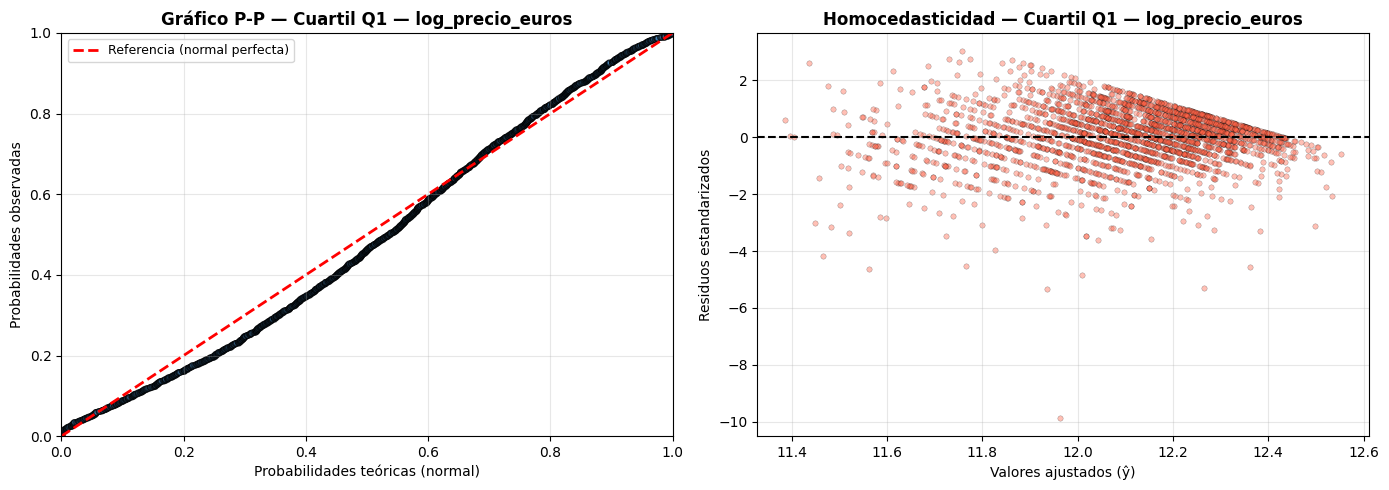

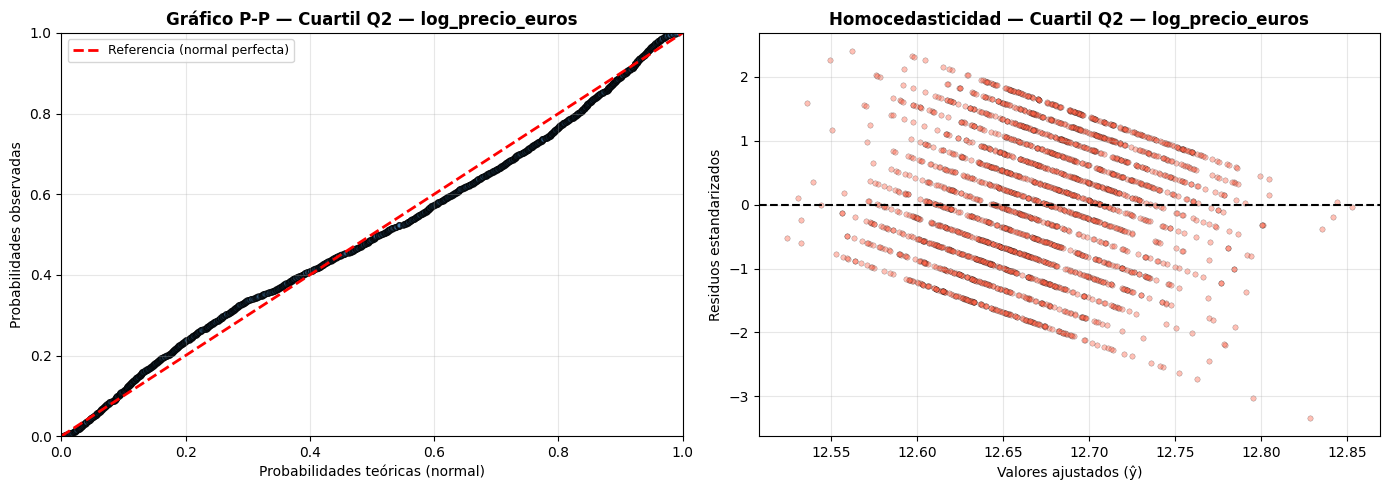

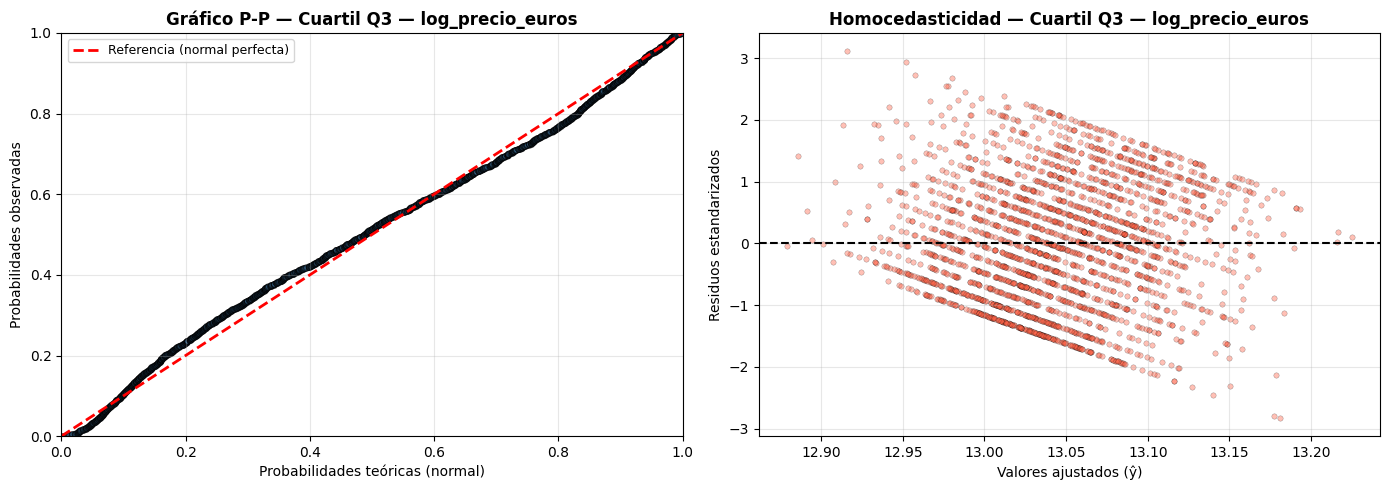

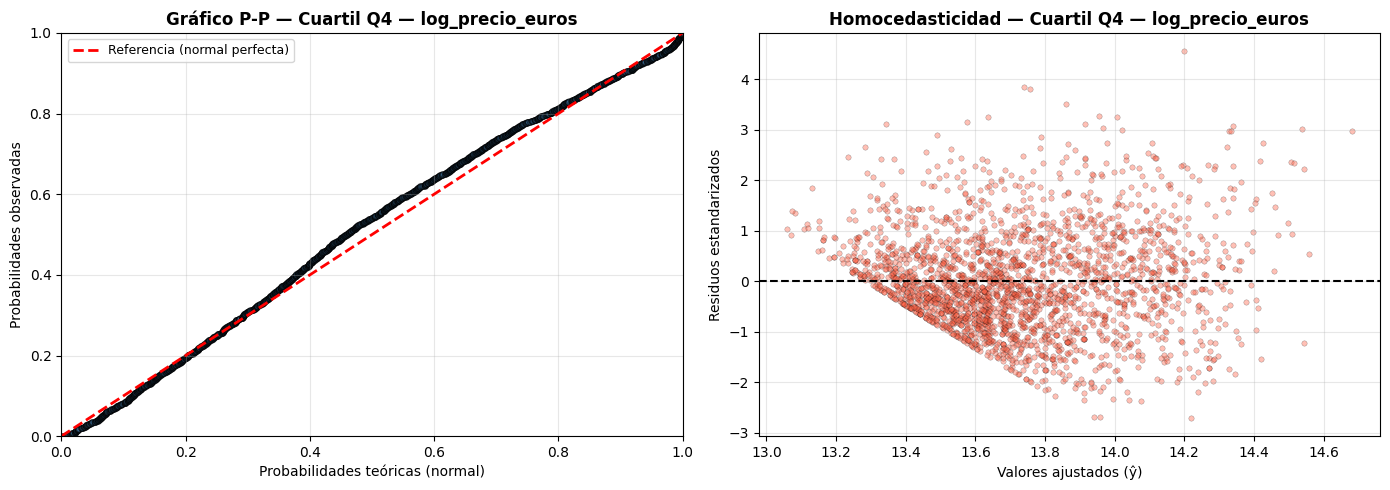

In [12]:
# ─── Diagnóstico de residuos de cada modelo ──────────────────────────────────
# Gráfico P-P + homocedasticidad para cada cuartil.

for cuartil in CUARTILES:
    if cuartil not in modelos_cuartil:
        continue
    diagnostico_residuos(
        modelos_cuartil[cuartil],
        titulo=f'Cuartil {cuartil} — {COL_Y}'
    )

---
## Paso 3 — Comparación del coeficiente de `superficie` entre cuartiles

La tabla y los gráficos siguientes muestran cómo varía el coeficiente β(superficie) según el segmento de precio.

> **Interpretación:** β(superficie) × 100 ≈ % de cambio en el precio por cada m² adicional, manteniendo el resto de variables constantes.
>
> Si β(Q4) > β(Q1), cada metro cuadrado adicional genera un incremento relativo de precio **mayor en las viviendas caras** que en las baratas.


In [13]:
# ─── Tabla comparativa de coeficientes y métricas ────────────────────────────

filas = []
for cuartil in CUARTILES:
    if cuartil not in modelos_cuartil:
        continue
    mod  = modelos_cuartil[cuartil]
    n    = int(mod.nobs)
    b_s  = betas_superficie[cuartil]
    b_s2 = betas_superficie_2[cuartil]
    vars_extra = [v for v in vars_cuartil[cuartil] if v not in VARS_FORZADAS]

    filas.append({
        'Cuartil':              cuartil,
        'n_obs':                n,
        'R²':                   round(mod.rsquared, 4),
        'AIC':                  round(mod.aic, 1),
        'β(superficie)':        round(b_s, 6),
        'p(superficie)':        round(mod.pvalues.get('superficie', np.nan), 4),
        'β(superficie_2)':      round(b_s2, 8),
        'p(superficie_2)':      round(mod.pvalues.get('superficie_2', np.nan), 4),
        'Vars. adicionales':    ', '.join(vars_extra) if vars_extra else '—',
    })

tabla_comparativa = pd.DataFrame(filas)

print("="*100)
print("COMPARATIVA DE MODELOS OLS POR CUARTIL DE PRECIO")
print("="*100)
display(tabla_comparativa)
print("="*100)

COMPARATIVA DE MODELOS OLS POR CUARTIL DE PRECIO


,Cuartil,n_obs,R²,AIC,β(superficie),p(superficie),β(superficie_2),p(superficie_2),Vars. adicionales
0,Q1,2333,0.4829,-663.8,0.008543,0.0000,-0.000027,0.0001,"desemp_pct, distancia_plaza_cat, interac_plant..."
1,Q2,2269,0.1667,-3640.9,0.003129,0.0001,-0.000009,0.0462,"distancia_plaza_cat, n_baños, interac_planta_a..."
2,Q3,2275,0.1811,-3625.5,0.003478,0.0000,-0.000008,0.0023,"rm_h, viv_prip_pct, n_baños, n_habs, distancia..."
3,Q4,2291,0.5726,-82.6,0.004233,0.0000,0.000001,0.5886,"viv_prip_pct, rm_h, n_habs, n_baños, calidad_c..."


---
## Paso 4 — Variable `beta_superficie` por observación

Ahora creamos una nueva columna en el dataset: **`beta_superficie`**.

Para cada oferta, el valor de esta variable es el coeficiente de `superficie` del modelo OLS estimado para el cuartil al que pertenece. Las ofertas del mismo cuartil comparten el mismo valor.


In [14]:
# ─── Crear variable beta_superficie ───────────────────────────────────────────
# Asignamos a cada oferta el β(superficie) del modelo de su cuartil.
# Resultado: las ofertas del mismo cuartil tienen el mismo valor de beta_superficie.
# Nota: se convierte a float porque pd.qcut genera una columna Categorical,
# y .map() sobre Categorical devuelve Categorical en lugar de numérico.
gdf['beta_superficie'] = gdf['cuartil_precio'].map(betas_superficie).astype(float)

# ─── Estadísticas descriptivas por cuartil ────────────────────────────────────
print("="*70)
print("VARIABLE: beta_superficie  (constante dentro de cada cuartil)")
print("="*70)
resumen_beta = gdf.groupby('cuartil_precio', observed=True).agg(
    n_obs=('beta_superficie', 'count'),
    beta_superficie=('beta_superficie', 'first'),
    sup_media=('superficie', 'mean'),
).round(6)
print(resumen_beta.to_string())
print("="*70)

print(f"\n✅ Columna creada: 'beta_superficie'")


VARIABLE: beta_superficie  (constante dentro de cada cuartil)
                n_obs  beta_superficie   sup_media
cuartil_precio                                    
Q1               2333         0.008543   65.640806
Q2               2269         0.003129   79.530630
Q3               2275         0.003478   94.795604
Q4               2291         0.004233  147.466172

✅ Columna creada: 'beta_superficie'


---
## Paso 5 — Distribución espacial de `beta_superficie`

El mapa siguiente muestra la distribución geográfica de `beta_superficie`: cada punto representa una oferta y el color indica el cuartil de precio al que pertenece.


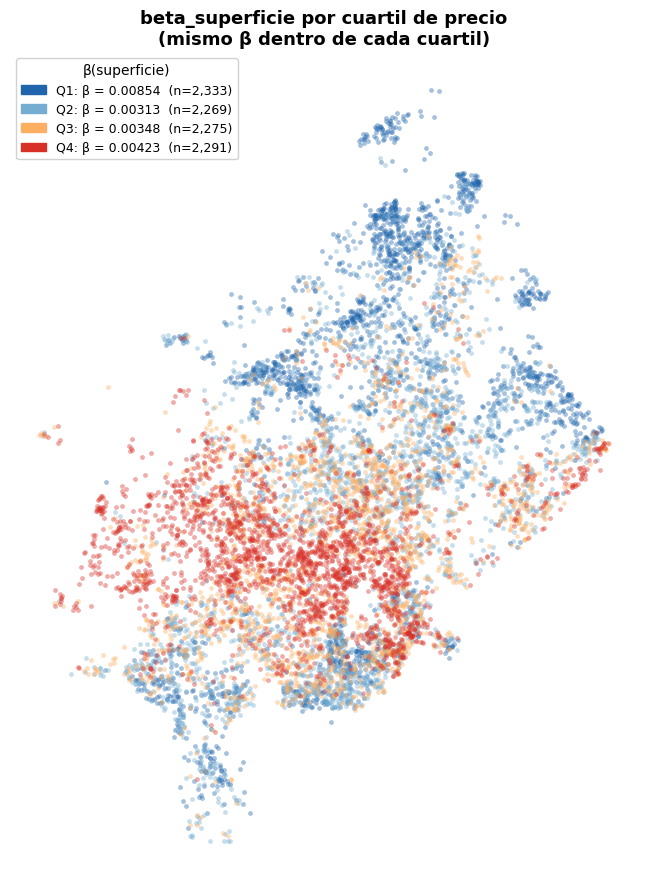

In [15]:
# ─── Mapa beta_superficie (discreto, 4 colores) ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))

for cuartil, color in COLORES_CUARTIL.items(): # Noten que `COLORES_CUARTIL` fue definido al inicio del cuaderno
    subset = gdf[gdf['cuartil_precio'] == cuartil]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, markersize=12, alpha=0.4, linewidth=0)

ax.set_title(
    'beta_superficie por cuartil de precio\n(mismo β dentro de cada cuartil)',
    fontsize=13, fontweight='bold'
)
ax.axis('off')

patches = [
    mpatches.Patch(
        color=COLORES_CUARTIL[q],
        label=f'{q}: β = {betas_superficie.get(q, float("nan")):.5f}'
              f'  (n={len(gdf[gdf["cuartil_precio"] == q]):,})'
    )
    for q in CUARTILES if q in betas_superficie
]
ax.legend(handles=patches, loc='upper left', fontsize=9,
          framealpha=0.9, title='β(superficie)')

plt.tight_layout()
plt.show()


---
## Paso 6 — Agregación de `beta_superficie` por sección censal

En los pasos anteriores cada **oferta** tiene asignado el β de su cuartil. Ahora trasladamos esa información a las **zonas** (secciones censales).

Para cada sección censal:
1. Se cuentan las ofertas por cuartil y se calcula la proporción de cada uno.
2. Se identifica el **cuartil predominante** (el de mayor proporción).
3. **Regla de mezcla:** si la diferencia entre el cuartil 1.º y el 2.º no supera el umbral del 5 % (en puntos porcentuales), se promedian sus betas en lugar de tomar solo el del primero.

| Caso | Ejemplo | Beta asignada |
|---|---|---|
| Cuartil dominante claro | Q3: 70 %, Q2: 20 % → dif. = 50 pp > 5 pp | β(Q3) |
| Zona de transición | Q2: 36 %, Q3: 33 % → dif. = 3 pp ≤ 5 pp | media(β(Q2), β(Q3)) |


⏳ Cargando secciones censales ajustadas...
✅ 324 zonas cargadas | CRS: EPSG:25831

RESULTADO POR ZONA  (umbral de mezcla: 5 pp)
  Zonas con al menos 1 oferta : 324
  Zonas con cuartil único     : 282
  Zonas mixtas (dif. ≤ 5%)  : 42

  Distribución por tipo de zona:
cuartil_zona
Q1       81
Q4       77
Q2       67
Q3       57
Q1+Q2     7
Q2+Q3     7
Q3+Q2     7
Q4+Q3     7
Q2+Q1     5
Q3+Q4     3
Q3+Q1     2
Q1+Q3     2
Q4+Q2     1
Q4+Q1     1


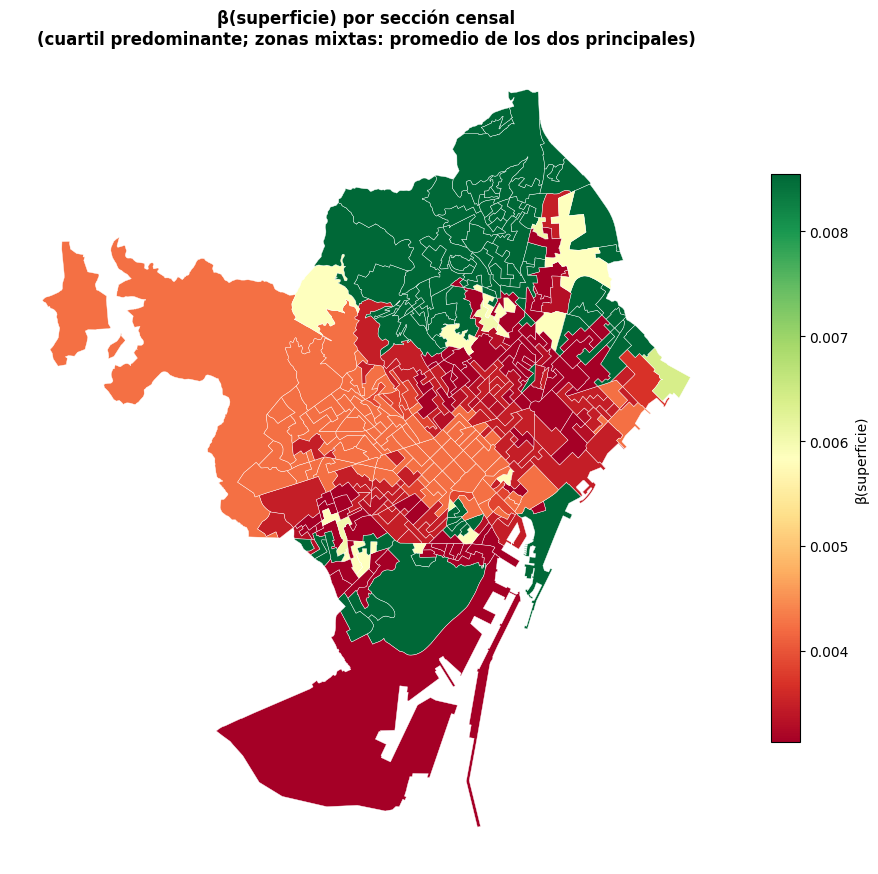

In [16]:
# ─── Cargar secciones censales ajustadas ─────────────────────────────────────
URL_SECCIONES = (
    "https://github.com/jose-rojasquiroz/jose-rojasquiroz.github.io"
    "/raw/main/teaching/srgvua_25_26/data/secciones_censales_ajustadas.gpkg"
)
print("⏳ Cargando secciones censales ajustadas...")
secciones = gpd.read_file(URL_SECCIONES)

if secciones.crs != gdf.crs:
    secciones = secciones.to_crs(gdf.crs)

secciones = secciones.reset_index(drop=True)
print(f"✅ {len(secciones)} zonas cargadas | CRS: {secciones.crs}")

# ─── Join espacial: cada oferta recibe el índice de la sección que la contiene ─
gdf_sj = gpd.sjoin(
    gdf[['geometry', 'cuartil_precio']].copy(),
    secciones[['geometry']],
    how='left', predicate='within'
)

# Limpiar y convertir a str para evitar problemas con dtype Categorical
gdf_sj_clean = gdf_sj.dropna(subset=['index_right', 'cuartil_precio']).copy()
gdf_sj_clean['cuartil_precio'] = gdf_sj_clean['cuartil_precio'].astype(str)

# ─── Contar ofertas por zona y cuartil ───────────────────────────────────────
conteo = (
    gdf_sj_clean
    .groupby(['index_right', 'cuartil_precio'])
    .size()
    .unstack(fill_value=0)
)
for q in CUARTILES:          # garantizar columnas Q1–Q4 aunque algún cuartil no aparezca
    if q not in conteo.columns:
        conteo[q] = 0
conteo = conteo[CUARTILES]

total_zona   = conteo.sum(axis=1)
proporciones = conteo.div(total_zona, axis=0)

# ─── Regla de asignación de beta ─────────────────────────────────────────────
# UMBRAL: diferencia máxima (en proporción) entre el 1º y 2º cuartil
# para que se promedien ambos betas en lugar de tomar solo el del 1º.
UMBRAL = 0.05   # 5 puntos porcentuales

def _cuartil_zona(fila):
    ord_ = fila.sort_values(ascending=False)
    q1, q2 = ord_.index[0], ord_.index[1]
    p1, p2 = ord_.iloc[0],  ord_.iloc[1]
    return f'{q1}+{q2}' if (p1 - p2) <= UMBRAL else q1

def _beta_zona(fila):
    ord_ = fila.sort_values(ascending=False)
    q1, q2 = ord_.index[0], ord_.index[1]
    p1, p2 = ord_.iloc[0],  ord_.iloc[1]
    b1 = betas_superficie.get(q1, np.nan)
    b2 = betas_superficie.get(q2, np.nan)
    return np.nanmean([b1, b2]) if (p1 - p2) <= UMBRAL else b1

secciones['n_ofertas']            = total_zona
secciones['cuartil_zona']         = proporciones.apply(_cuartil_zona, axis=1)
secciones['beta_superficie_zona'] = proporciones.apply(_beta_zona,    axis=1)

# ─── Resumen ─────────────────────────────────────────────────────────────────
n_con_datos = secciones['n_ofertas'].notna().sum()
n_mixtas    = secciones['cuartil_zona'].str.contains(r'\+', na=False).sum()

print(f"\n{'='*65}")
print(f"RESULTADO POR ZONA  (umbral de mezcla: {UMBRAL*100:.0f} pp)")
print(f"{'='*65}")
print(f"  Zonas con al menos 1 oferta : {n_con_datos}")
print(f"  Zonas con cuartil único     : {n_con_datos - n_mixtas}")
print(f"  Zonas mixtas (dif. ≤ {UMBRAL*100:.0f}%)  : {n_mixtas}")
print(f"\n  Distribución por tipo de zona:")
print(secciones['cuartil_zona'].value_counts().to_string())
print(f"{'='*65}")

# ─── Mapa de beta_superficie_zona ─────────────────────────────────────────────
secciones_plot = secciones[secciones['beta_superficie_zona'].notna()].copy()
vmin_z = secciones_plot['beta_superficie_zona'].quantile(0.05)
vmax_z = secciones_plot['beta_superficie_zona'].quantile(0.95)

fig, ax = plt.subplots(figsize=(10, 9))
secciones_plot.plot(
    column='beta_superficie_zona', cmap='RdYlGn',
    ax=ax, legend=True, vmin=vmin_z, vmax=vmax_z,
    edgecolor='white', linewidth=0.3,
    legend_kwds={'label': 'β(superficie)', 'shrink': 0.7}
)
ax.set_title(
    'β(superficie) por sección censal\n'
    '(cuartil predominante; zonas mixtas: promedio de los dos principales)',
    fontsize=12, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
plt.show()

---
## 💾 Guardar resultados en Google Drive

Guardamos dos archivos: el dataset de **ofertas** con las columnas creadas en este cuaderno, y el de **secciones censales** con la beta asignada por zona.

| Archivo | Contenido |
|---|---|
| `datos_cuaderno4.gpkg` | Ofertas individuales con `cuartil_precio` y `beta_superficie` |
| `secciones_cuaderno4.gpkg` | Secciones censales con `n_ofertas`, `cuartil_zona` y `beta_superficie_zona` |


In [17]:
# ✏️ MODIFICA AQUÍ — Rutas de salida en tu Google Drive
RUTA_SALIDA_C4 = "/content/drive/MyDrive/srgvua/datos_cuaderno4.gpkg"
RUTA_SECCIONES = "/content/drive/MyDrive/srgvua/secciones_cuaderno4.gpkg"

os.makedirs(os.path.dirname(RUTA_SALIDA_C4), exist_ok=True)

# ─── Guardar ofertas ──────────────────────────────────────────────────────────
gdf.to_file(RUTA_SALIDA_C4, driver='GPKG')
print(f"✅ Ofertas guardadas  → {RUTA_SALIDA_C4}")
print(f"   {gdf.shape[0]:,} filas × {gdf.shape[1]} columnas")
print(f"   Columnas nuevas: cuartil_precio | beta_superficie")

# ─── Guardar secciones censales ───────────────────────────────────────────────
secciones.to_file(RUTA_SECCIONES, driver='GPKG')
print(f"\n✅ Secciones guardadas → {RUTA_SECCIONES}")
print(f"   {len(secciones)} zonas")
print(f"   Columnas nuevas: n_ofertas | cuartil_zona | beta_superficie_zona")

print(f"\n💡 Para cargar en otro cuaderno:")
print(f"   gdf       = gpd.read_file('{RUTA_SALIDA_C4}')")
print(f"   secciones = gpd.read_file('{RUTA_SECCIONES}')")


✅ Ofertas guardadas  → /content/drive/MyDrive/srgvua/datos_cuaderno4.gpkg
   9,168 filas × 55 columnas
   Columnas nuevas: cuartil_precio | beta_superficie

✅ Secciones guardadas → /content/drive/MyDrive/srgvua/secciones_cuaderno4.gpkg
   324 zonas
   Columnas nuevas: n_ofertas | cuartil_zona | beta_superficie_zona

💡 Para cargar en otro cuaderno:
   gdf       = gpd.read_file('/content/drive/MyDrive/srgvua/datos_cuaderno4.gpkg')
   secciones = gpd.read_file('/content/drive/MyDrive/srgvua/secciones_cuaderno4.gpkg')
